In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_dir = "data"
data_files = os.listdir(data_dir)
output_files = [f for f in data_files if "hf_output" in f]
print(len(output_files))

9


In [3]:
output_file = output_files[0]
with open(data_dir + "/" + output_file, "r") as f:
    output_dict = json.load(f)
dmrg_energy = output_dict["dmrg_energy"]
krylov_energy_records = []
for d_str, energy in output_dict["kyrlov_energies"]["energy"].items():
    krylov_energy_records.append((int(d_str), energy))
krylov_energies_df = pd.DataFrame.from_records(krylov_energy_records, columns=["d", "energy"])
krylov_energies_df.set_index("d")
krylov_energies_df["chi_dmrg"] = output_dict["input"]["chi_dmrg"]
krylov_energies_df["chi_tdvp"] = output_dict["input"]["chi_tdvp"]
print(krylov_energies_df.head())

   d     energy  chi_dmrg  chi_tdvp
0  1 -98.035037        15        40
1  2 -98.115308        15        40
2  3 -98.318943        15        40
3  4 -98.338302        15        40
4  5 -98.375899        15        40


In [4]:
krylov_energy_dfs = [] # List of dataframe mapping d to energy. Each df is a different bond dim.
dmrg_energy_dict = {} # Maps bond dimension to the DMRG energy.

for output_file in output_files:
    with open(data_dir + "/" + output_file, "r") as f:
        output_dict = json.load(f)
    dmrg_energy = output_dict["dmrg_energy"]
    dmrg_energy_dict[output_dict["input"]["chi_dmrg"]] = dmrg_energy
    krylov_energy_records = []
    for d_str, energy in output_dict["kyrlov_energies"]["energy"].items():
        krylov_energy_records.append((int(d_str), energy))
    krylov_energies_df = pd.DataFrame.from_records(krylov_energy_records, columns=["d", "energy"])
    krylov_energies_df.set_index("d")
    krylov_energies_df["chi_dmrg"] = output_dict["input"]["chi_dmrg"]
    krylov_energies_df["chi_tdvp"] = output_dict["input"]["chi_tdvp"]
    krylov_energy_dfs.append(krylov_energies_df)

In [5]:
big_df = pd.concat(krylov_energy_dfs)
print(big_df.head())

   d     energy  chi_dmrg  chi_tdvp
0  1 -98.035037        15        40
1  2 -98.115308        15        40
2  3 -98.318943        15        40
3  4 -98.338302        15        40
4  5 -98.375899        15        40


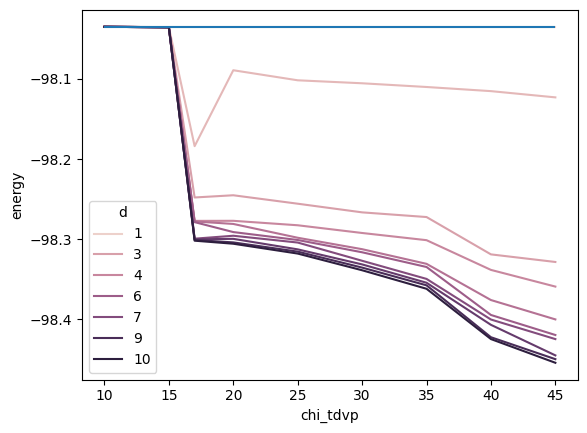

In [7]:
fig, ax = plt.subplots()
sns.lineplot(ax=ax, data=big_df, x="chi_tdvp", hue="d", y="energy")
ax.hlines([dmrg_energy], 10, 45)